<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_3_Covariance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Preliminaries: Covariance and Correlation


---



## What This Notebook Is About

In our last notebook, a dinosaur taught us a vital lesson: our eyes can see patterns that summary statistics miss. We now have a visual feel for how variables "move together."  But visual intuition doesn't scale. We can't eyeball a regression model into existence, and we can't compare thousands of variables by hand. We need a metric.

In this notebook, we will "invent" that metric twice. Our goal is to answer one question:
* How do we compress the 2D shape of a scatterplot into a single, honest number that measures the strength of a relationship?

We'll start with **covariance**, which tells us the direction of a relationship but suffers from a major "scaling" flaw. Then, we’ll fix that flaw to create **Pearson’s correlation coefficient**, perhaps the most influential number in all of statistics.

## Setup

We'll keep going with the Palmer Penguins dataset. Our $x$ will be **flipper length (mm)** and our $y$ will be **body mass (g)**. We drop any rows missing either measurement so the math is clean.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

penguins = sns.load_dataset('penguins').dropna(
    subset=['flipper_length_mm', 'body_mass_g']
)

x = penguins['flipper_length_mm'].to_numpy()   # our X (mm)
y = penguins['body_mass_g'].to_numpy()         # our Y (g)

print(f'Number of penguins: {len(x)}')
print(f'First 5 flipper lengths (mm): {x[:5]}')
print(f'First 5 body masses (g):      {y[:5]}')

Number of penguins: 342
First 5 flipper lengths (mm): [181. 186. 195. 193. 190.]
First 5 body masses (g):      [3750. 3800. 3250. 3450. 3650.]


---

## Section 1: The Quadrant Trick

### First, look at the data (always!)

Notebook 2 drilled one rule into us: **never analyze data you haven't looked at.** So let's start with the picture.

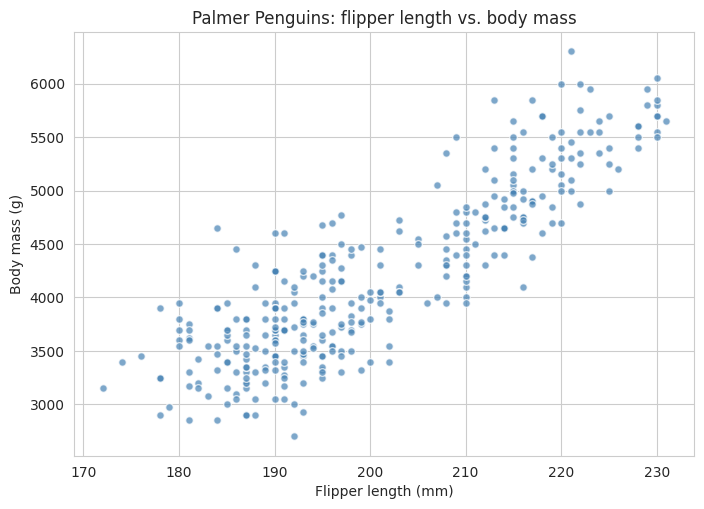

In [2]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(x, y, s=30, alpha=0.7, color='steelblue', edgecolor='white')
ax.set_xlabel('Flipper length (mm)')
ax.set_ylabel('Body mass (g)')
ax.set_title('Palmer Penguins: flipper length vs. body mass')
plt.show()

There's a clear positive, roughly linear trend. As flippers get longer, penguins get heavier. That's what the scatterplot shows us.

But how do we prove this with a number? How do we capture "the points drift up and to the right" mathematically?

We'll reuse an idea we already know well, deviations from the mean (from Notebook 1), and apply it to both variables at once.

### Drawing the quadrants

Let's draw two reference lines through our scatterplot: a vertical line at the mean of $x$, and a horizontal line at the mean of $y$.

Mean flipper length: 200.92 mm
Mean body mass:      4201.75 g


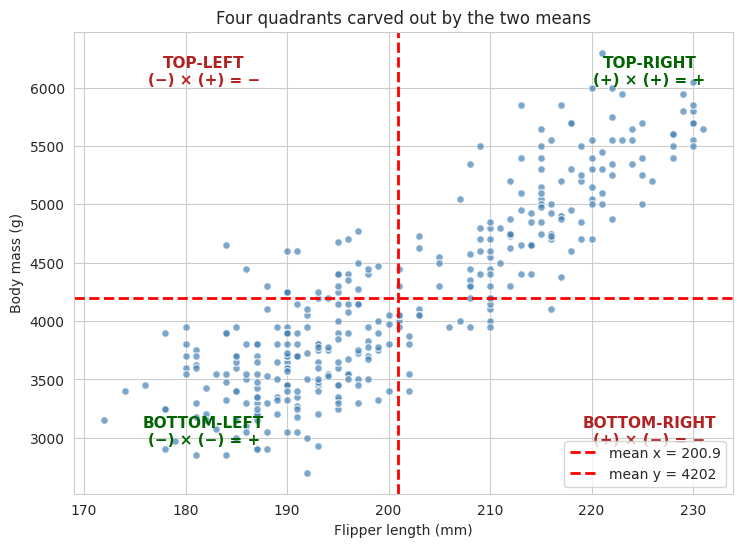

In [3]:
x_mean = np.mean(x)
y_mean = np.mean(y)

print(f'Mean flipper length: {x_mean:.2f} mm')
print(f'Mean body mass:      {y_mean:.2f} g')

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(x, y, s=30, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(x_mean, color='red', linestyle='--', linewidth=2, label=f'mean x = {x_mean:.1f}')
ax.axhline(y_mean, color='red', linestyle='--', linewidth=2, label=f'mean y = {y_mean:.0f}')

# Label the four quadrants
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(x_mean + 0.75*(xlim[1]-x_mean), y_mean + 0.80*(ylim[1]-y_mean),
        'TOP-RIGHT\n(+) \u00d7 (+) = +', ha='center', fontsize=11,
        color='darkgreen', weight='bold')
ax.text(x_mean - 0.60*(x_mean-xlim[0]), y_mean - 0.75*(y_mean-ylim[0]),
        'BOTTOM-LEFT\n(\u2212) \u00d7 (\u2212) = +', ha='center', fontsize=11,
        color='darkgreen', weight='bold')
ax.text(x_mean - 0.60*(x_mean-xlim[0]), y_mean + 0.80*(ylim[1]-y_mean),
        'TOP-LEFT\n(\u2212) \u00d7 (+) = \u2212', ha='center', fontsize=11,
        color='firebrick', weight='bold')
ax.text(x_mean + 0.75*(xlim[1]-x_mean), y_mean - 0.75*(y_mean-ylim[0]),
        'BOTTOM-RIGHT\n(+) \u00d7 (\u2212) = \u2212', ha='center', fontsize=11,
        color='firebrick', weight='bold')

ax.set_xlabel('Flipper length (mm)')
ax.set_ylabel('Body mass (g)')
ax.set_title('Four quadrants carved out by the two means')
ax.legend(loc='lower right')
plt.show()

### Interpreting the Quadrants

The two mean lines carve the scatterplot into four quadrants. Here's what's happening in each one:

- **Top-right:** $x$ is *above* its mean (so $x_i - \bar{x}$ is **positive**) AND $y$ is *above* its mean (so $y_i - \bar{y}$ is **positive**). Product: **positive × positive = positive**.
- **Bottom-left:** both deviations are **negative**. Product: **negative × negative = positive**.
- **Top-left and bottom-right:** one deviation is positive and the other is negative. Product: **negative**.

Now look at the penguin scatterplot. Where do almost all the points live? In the top-right and bottom-left. That's what "positive linear relationship" looks like, geometrically.

So here's the plan: for every penguin, compute the product $(x_i - \bar{x})(y_i - \bar{y})$. Then add them all up.

- If the data slopes up: most products are positive, they add to a big positive number.
- If the data slopes down: most products are negative, they add to a big negative number.
- If there's no relationship at all: the positives and negatives cancel and we get something near zero.

We are calculating a single number that captures the direction and strength of co-movement. That's exactly what we wanted. This value is called the Sum of the Cross-Products. It isn't typically reported in statistical analyses, so we won't emphasize it — just consider it a step on our way to calculating covariance.

---

## Section 2: Covariance

### The formula

If we add up the products $(x_i - \bar{x})(y_i - \bar{y})$ across all penguins, that total will grow as we add more data (same problem we had with TSS in notebook 1). So, as before, we divide by $N$ to get an *average* per-penguin product. That gives us **covariance**:

$$\text{Cov}(x, y) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})$$

> As with variance, you'll sometimes see this written with $N-1$ in the denominator for sample estimates. We'll stick with $N$ here to keep things conceptual. NumPy's `np.cov` uses $N-1$ by default, which is why the numbers below will differ slightly from `np.cov`.

Let's compute it.

In [4]:
x_dev = x - x_mean          # deviation of each flipper length from the mean
y_dev = y - y_mean          # deviation of each body mass from the mean
products = x_dev * y_dev    # the (x_i - x_bar)(y_i - y_bar) for each penguin

covariance = np.mean(products)
print(f'Covariance (flipper mm, body mass g): {covariance:.2f}')

Covariance (flipper mm, body mass g): 9795.69


### Covariance has a problem: units

Our covariance is about **9,796**. That's a big number!  Sounds like a strong relationship. But immediately, a question should bug you:

> *9,796... **what**?*

Look at the formula again. We multiplied a thing in **millimeters** by a thing in **grams**. Our covariance has units of **millimeter · grams**. That is not a quantity that means anything in the real world. You can't hold 9,796 mm·g in your hand.

Worse, the number depends on which units we happen to choose. Watch.

In [5]:
# Convert body mass from grams to kilograms. This is a purely cosmetic
# change -- the physical reality of the penguins has not shifted one bit.
y_kg = y / 1000.0

y_kg_dev = y_kg - y_kg.mean()
covariance_kg = np.mean(x_dev * y_kg_dev)

print(f'Covariance in mm \u00b7 grams:     {covariance:,.2f}')
print(f'Covariance in mm \u00b7 kilograms: {covariance_kg:,.4f}')
print(f'Ratio: {covariance / covariance_kg:,.0f}x')

Covariance in mm · grams:     9,795.69
Covariance in mm · kilograms: 9.7957
Ratio: 1,000x


Our covariance **shrank by a factor of 1000** just because we decided to write weights in kilograms instead of grams.

Did the penguins change? No. The scatterplot would look *identical*. Only the axis labels would change. But the summary number we use to describe the relationship changed by three orders of magnitude.

This is a fatal flaw for comparison purposes. If I tell you "flipper length and body mass have covariance 9796" and you tell me "bill length and body mass have covariance 4", we have no way to tell whether 9796 is a stronger relationship than 4, or just a relationship measured in different units.

### The core lesson

> **Covariance tells us the *direction* of a linear relationship (positive, negative, or roughly zero), but its magnitude is entirely at the mercy of whatever units we picked. It is unbounded and not comparable across datasets.**

We need to fix this.

---

## Section 3: Pearson's $r$ (Correlation)

### The idea: divide the units away

Covariance has units of (x-units · y-units). We need to get rid of those units. The trick is obvious once you see it: **divide by something that also has those units, so they cancel.**

What do we know that has units of x? The standard deviation of $x$ (from notebook 1) is in the same units as the original variable). Same for $y$.

So: divide covariance by $\sigma_x \cdot \sigma_y$. The units $(\text{mm} \cdot \text{g})$ in the numerator cancel the units $(\text{mm}) \cdot (\text{g})$ in the denominator, leaving a pure, unitless number.

That number is **Pearson's correlation coefficient**, almost always written $r$:

$$r = \frac{\text{Cov}(x, y)}{\sigma_x \cdot \sigma_y}$$

Another way to read this: $r$ is covariance **standardized** by the spread of each variable. It asks, "Given how much x typically wobbles and how much y typically wobbles, how much do they wobble *together*?"

### Your Turn: Implement Pearson's $r$

Fill in the body of the function below so that it returns Pearson's $r$ for two arrays `x` and `y`. Use only basic NumPy operations (`np.mean`, `np.sqrt`, `**`, etc.). Don't use `np.corrcoef` or any stats library function that does the whole calculation for you. The point is to see it built from the pieces we already know.

**Reminder of the pieces you've already built:**
- Standard deviation = $\sqrt{\frac{1}{N}\sum (x_i - \bar{x})^2}$ (notebook 1)
- Covariance = $\frac{1}{N}\sum (x_i - \bar{x})(y_i - \bar{y})$ (this notebook)

In [6]:
def calculate_pearson_r(x, y):
    """Return Pearson's r: Cov(x,y) / (std_x * std_y)."""
    # TODO: your code here
    pass

# Uncomment to test once you've filled in the function:
# r = calculate_pearson_r(x, y)
# print(f"Pearson's r (flipper mm, body mass g): {r:.4f}")

In [7]:
# @title Execute cell to see a solution.

print('''
def calculate_pearson_r(x, y):
    x_dev = x - np.mean(x)
    y_dev = y - np.mean(y)
    covariance = np.mean(x_dev * y_dev)
    std_x = np.sqrt(np.mean(x_dev ** 2))
    std_y = np.sqrt(np.mean(y_dev ** 2))
    return covariance / (std_x * std_y)
    ''')

def calculate_pearson_r(x, y):
    x_dev = x - np.mean(x)
    y_dev = y - np.mean(y)
    covariance = np.mean(x_dev * y_dev)
    std_x = np.sqrt(np.mean(x_dev ** 2))
    std_y = np.sqrt(np.mean(y_dev ** 2))
    return covariance / (std_x * std_y)

r = calculate_pearson_r(x, y)
print(f"Pearson's r (flipper mm, body mass g): {r:.4f}")
print(f"NumPy check (np.corrcoef):              {np.corrcoef(x, y)[0, 1]:.4f}")


def calculate_pearson_r(x, y):
    x_dev = x - np.mean(x)
    y_dev = y - np.mean(y)
    covariance = np.mean(x_dev * y_dev)
    std_x = np.sqrt(np.mean(x_dev ** 2))
    std_y = np.sqrt(np.mean(y_dev ** 2))
    return covariance / (std_x * std_y)
    
Pearson's r (flipper mm, body mass g): 0.8712
NumPy check (np.corrcoef):              0.8712


### The payoff: $r$ is unit-proof

Remember how covariance collapsed by a factor of 1000 when we switched grams to kilograms? Let's run our function on the kilogram version of the weights and see what happens.

In [8]:
r_grams     = calculate_pearson_r(x, y)       # flipper mm, body mass in grams
r_kilograms = calculate_pearson_r(x, y_kg)    # flipper mm, body mass in kilograms

print(f'r with grams:     {r_grams:.6f}')
print(f'r with kilograms: {r_kilograms:.6f}')

r with grams:     0.871202
r with kilograms: 0.871202


Identical, to every digit of precision.

This is not a lucky coincidence. It's the whole point. The standard deviations carried the same units as the covariance, so when we divided, the units canceled perfectly. Convert the flipper lengths to centimeters or meters, and you'll get 0.8712 there too.

### What $r$ means

Pearson's $r$ is provably bounded:

$$-1 \le r \le 1$$

With a few reference points to build intuition:

| $r$ | Meaning |
|---|---|
| **$+1.0$** | Perfect upward line — every point exactly on it. |
| **$\approx 0.7$ to $+1.0$** | Strong positive linear relationship. |
| **$\approx 0.3$ to $0.7$** | Moderate positive linear relationship. |
| **$\approx 0$** | No linear relationship. |
| **$\approx -0.3$ to $-0.7$** | Moderate negative linear relationship. |
| **$-1.0$** | Perfect downward line. |

Our penguin data: $r \approx 0.871$. That's a **strong positive linear relationship** between flipper length and body mass. It's also *unitless*; true whether we measure weight in grams, kilograms, or stones.

### One important warning

Pearson's $r$ only measures *linear* relationships. It is blind to curves and to shape. A dataset that looks like Anscombe's Dataset II (a perfect parabola) can have an $r$ that suggests a modest linear trend even though the real underlying relationship is deterministic and non-linear.

In other words: $r$ doesn't free you from looking at your data. It just gives you a compact number to report *after* you've confirmed that a line is a reasonable description of the shape.

---

## Putting It All Together

Our story so far:

| Concept | Formula | What it tells us | Downside |
|---|---|---|---|
| **Covariance** | $\frac{1}{N}\sum (x_i-\bar{x})(y_i-\bar{y})$ | Direction of the linear relationship | Units are weird; magnitude not comparable across datasets |
| **Correlation ($r$)** | $\frac{\text{Cov}(x,y)}{\sigma_x \sigma_y}$ | Direction *and* strength, on a fixed $[-1, +1]$ scale | Only sees *linear* relationships |

And the main takeaway:

> **Covariance gives us the *direction* of co-movement. Dividing by the standard deviations cancels the units and bounds the result between $-1$ and $+1$. That standardized number is Pearson's correlation coefficient, $r$.**

### Where We're Going Next

We can now put a number to how strongly two variables move together. But $r$ still doesn't let us *predict* anything. If a new penguin walks in with a 200 mm flipper, $r = 0.871$ doesn't tell us its weight in grams. It just tells us the relationship is strong.

To predict, we need to actually draw a line through the data. A line that lets us say *"for a flipper length of $x$, the predicted body mass is $\hat{y}$."* And to pick the **best** line out of all the possible lines, we need a way to measure how wrong each candidate line is.

That measurement is called a **residual**, and it's the subject of [the next notebook](https://github.com/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_4_Residuals.ipynb)-->